In [1]:
import pandas as pd

orders_df = pd.read_excel("orders.xlsx")
orders_df.head()

,Customer Reference,Document Date,Sales Document Type,Sales Document,Sales Document Item,Sold-to Party,Material,Order Quantity (Item),Sales Unit,Net Value (Item),...,Address Blocked (Sold-To),Requirement Segment,Address Blocked (Partner),Employee ID,Action Description,Item Category,AF Open Confirmed quantity,Af Open Confirmed Value,Complete name,AF Open Order Quantity
0,900297758 Returned,2025-11-18,ZRE,60012403,320,17161,90183-05042,300,EA,7627.50,...,NaN,NaN,NaN,NaN,NaN,ZRN1,300,300.0,Danushka Bandara,0
1,900297758 Returned,2025-11-18,ZRE,60012403,330,17161,90506-12001,15,EA,10010.59,...,NaN,NaN,NaN,NaN,NaN,ZRN1,15,15.0,Danushka Bandara,0
2,900297758 Returned,2025-11-18,ZRE,60012403,340,17161,90506-15001,20,EA,14364.45,...,NaN,NaN,NaN,NaN,NaN,ZRN1,20,20.0,Danushka Bandara,0
3,900287870 Retuned,2025-11-18,ZRE,60012402,50,39012,5GH-13440-80,10,EA,32045.00,...,NaN,NaN,NaN,NaN,NaN,ZRN1,10,10.0,Danushka Bandara,0
4,900306707 PARTS RETURN,2025-09-11,ZRE,60012101,50,27910,B4G-XF17D-00-00,1,EA,1398.31,...,NaN,NaN,NaN,NaN,NaN,ZRN1,1,1.0,Danushka Bandara,0


In [3]:
# Convert date columns to datetime (errors='coerce' will turn invalid dates into NaT)
orders_df['Created On'] = pd.to_datetime(orders_df['Created On'], errors='coerce')
orders_df['Goods Issue Date'] = pd.to_datetime(orders_df['Goods Issue Date'], errors='coerce')

# Calculate Lead Time (in days)
orders_df['Lead Time'] = (orders_df['Goods Issue Date'] - orders_df['Created On']).dt.days

# Ensure quantity columns are numeric
orders_df['Order Quantity (Item)'] = pd.to_numeric(orders_df['Order Quantity (Item)'], errors='coerce')
orders_df['Confirmed Quantity (Item)'] = pd.to_numeric(orders_df['Confirmed Quantity (Item)'], errors='coerce')

# Calculate Lost Qty
orders_df['Lost Qty'] = orders_df['Order Quantity (Item)'] - orders_df['Confirmed Quantity (Item)']

In [4]:
orders_df.head(10)

,Customer Reference,Document Date,Sales Document Type,Sales Document,Sales Document Item,Sold-to Party,Material,Order Quantity (Item),Sales Unit,Net Value (Item),...,Address Blocked (Partner),Employee ID,Action Description,Item Category,AF Open Confirmed quantity,Af Open Confirmed Value,Complete name,AF Open Order Quantity,Lead Time,Lost Qty
0,900297758 Returned,2025-11-18,ZRE,60012403,320,17161,90183-05042,300,EA,7627.50,...,NaN,NaN,NaN,ZRN1,300,300.0,Danushka Bandara,0,0.0,0.0
1,900297758 Returned,2025-11-18,ZRE,60012403,330,17161,90506-12001,15,EA,10010.59,...,NaN,NaN,NaN,ZRN1,15,15.0,Danushka Bandara,0,0.0,0.0
2,900297758 Returned,2025-11-18,ZRE,60012403,340,17161,90506-15001,20,EA,14364.45,...,NaN,NaN,NaN,ZRN1,20,20.0,Danushka Bandara,0,0.0,0.0
3,900287870 Retuned,2025-11-18,ZRE,60012402,50,39012,5GH-13440-80,10,EA,32045.00,...,NaN,NaN,NaN,ZRN1,10,10.0,Danushka Bandara,0,0.0,0.0
4,900306707 PARTS RETURN,2025-09-11,ZRE,60012101,50,27910,B4G-XF17D-00-00,1,EA,1398.31,...,NaN,NaN,NaN,ZRN1,1,1.0,Danushka Bandara,0,0.0,0.0
5,900273244 - Return,2025-11-27,ZRE,60012031,60,119237,B3424689,12,EA,190296.61,...,NaN,NaN,NaN,ZRN1,12,12.0,Aseni Savinya,0,0.0,0.0
6,900273244 - Return,2025-11-27,ZRE,60012031,70,119237,B3431613,48,EA,78459.66,...,NaN,NaN,NaN,ZRN1,48,48.0,Aseni Savinya,0,0.0,0.0
7,900273244 - Return,2025-11-27,ZRE,60012031,80,119237,B87520219,34,EA,57189.15,...,NaN,NaN,NaN,ZRN1,34,34.0,Aseni Savinya,0,0.0,0.0
8,900247770 - Return,2025-11-27,ZRE,60012030,110,119237,B3375771,3,EA,7102.37,...,NaN,NaN,NaN,ZRN1,3,3.0,Aseni Savinya,0,0.0,0.0
9,900241197 - Return,2025-11-27,ZRE,60012029,50,119237,B71391919N,1,EA,295652.33,...,NaN,NaN,NaN,ZRN1,1,1.0,Aseni Savinya,0,0.0,0.0


In [9]:
empty_cols = orders_df.columns[orders_df.isnull().all()]
print("Columns with all null values:", empty_cols)

Columns with all null values: Index(['Billing Block', 'Sales Document Description', 'Exchange Rate Type',
       'Delivery Block', 'Batch', 'Personnel Partner Function',
       'Partner Function', 'Address Number', 'Partner', 'Partner Name',
       'Unit Validity Period', 'Val.Period.Category', 'Installation Date',
       'Acceptance Date', 'Contract Signed', 'Contract Start Date',
       'Contract End Date', 'Cancellation Proced.', 'Action',
       'Receipt of Canc.', 'Req.Cancellat.Date', 'Cancellation Party',
       'Reason for Cancel.', 'Cancel.Doc.for Part.', 'Date of Canc.Doc.',
       'Dismantling Date', 'Action Date', 'Delivery Block Description',
       'Billing Block Description', 'Personnel Name',
       'Address Blocked (Sold-To)', 'Requirement Segment',
       'Address Blocked (Partner)', 'Employee ID', 'Action Description'],
      dtype='object')


In [10]:
orders_df.drop(columns=empty_cols, inplace=True)

In [11]:
orders_df.head(10)

,Customer Reference,Document Date,Sales Document Type,Sales Document,Sales Document Item,Sold-to Party,Material,Order Quantity (Item),Sales Unit,Net Value (Item),...,Distribution Channel Name,Division Name,Sales Document Type Description,Item Category,AF Open Confirmed quantity,Af Open Confirmed Value,Complete name,AF Open Order Quantity,Lead Time,Lost Qty
0,900297758 Returned,2025-11-18,ZRE,60012403,320,17161,90183-05042,300,EA,7627.50,...,Parts sales,Common,Sales Return,ZRN1,300,300.0,Danushka Bandara,0,0.0,0.0
1,900297758 Returned,2025-11-18,ZRE,60012403,330,17161,90506-12001,15,EA,10010.59,...,Parts sales,Common,Sales Return,ZRN1,15,15.0,Danushka Bandara,0,0.0,0.0
2,900297758 Returned,2025-11-18,ZRE,60012403,340,17161,90506-15001,20,EA,14364.45,...,Parts sales,Common,Sales Return,ZRN1,20,20.0,Danushka Bandara,0,0.0,0.0
3,900287870 Retuned,2025-11-18,ZRE,60012402,50,39012,5GH-13440-80,10,EA,32045.00,...,Parts sales,Common,Sales Return,ZRN1,10,10.0,Danushka Bandara,0,0.0,0.0
4,900306707 PARTS RETURN,2025-09-11,ZRE,60012101,50,27910,B4G-XF17D-00-00,1,EA,1398.31,...,Parts sales,Common,Sales Return,ZRN1,1,1.0,Danushka Bandara,0,0.0,0.0
5,900273244 - Return,2025-11-27,ZRE,60012031,60,119237,B3424689,12,EA,190296.61,...,Parts sales,Lubricant,Sales Return,ZRN1,12,12.0,Aseni Savinya,0,0.0,0.0
6,900273244 - Return,2025-11-27,ZRE,60012031,70,119237,B3431613,48,EA,78459.66,...,Parts sales,Lubricant,Sales Return,ZRN1,48,48.0,Aseni Savinya,0,0.0,0.0
7,900273244 - Return,2025-11-27,ZRE,60012031,80,119237,B87520219,34,EA,57189.15,...,Parts sales,Lubricant,Sales Return,ZRN1,34,34.0,Aseni Savinya,0,0.0,0.0
8,900247770 - Return,2025-11-27,ZRE,60012030,110,119237,B3375771,3,EA,7102.37,...,Parts sales,Lubricant,Sales Return,ZRN1,3,3.0,Aseni Savinya,0,0.0,0.0
9,900241197 - Return,2025-11-27,ZRE,60012029,50,119237,B71391919N,1,EA,295652.33,...,Parts sales,Lubricant,Sales Return,ZRN1,1,1.0,Aseni Savinya,0,0.0,0.0


Lead Time Statistics (days)
count    52452.000000
mean         3.360406
std         14.059622
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        348.000000
Name: Lead Time, dtype: float64


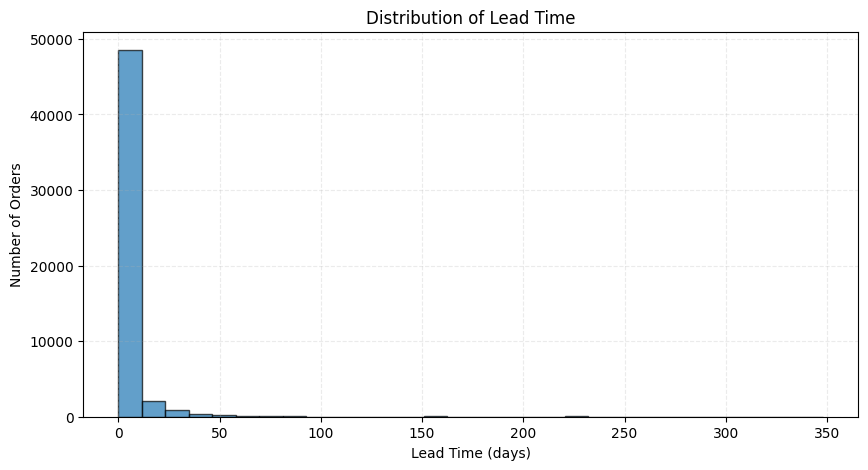

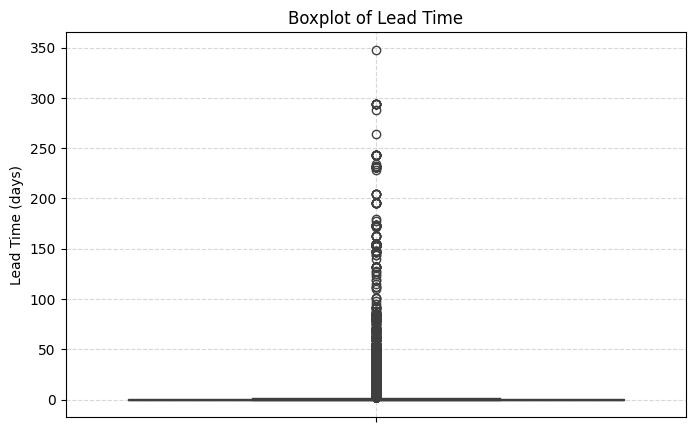

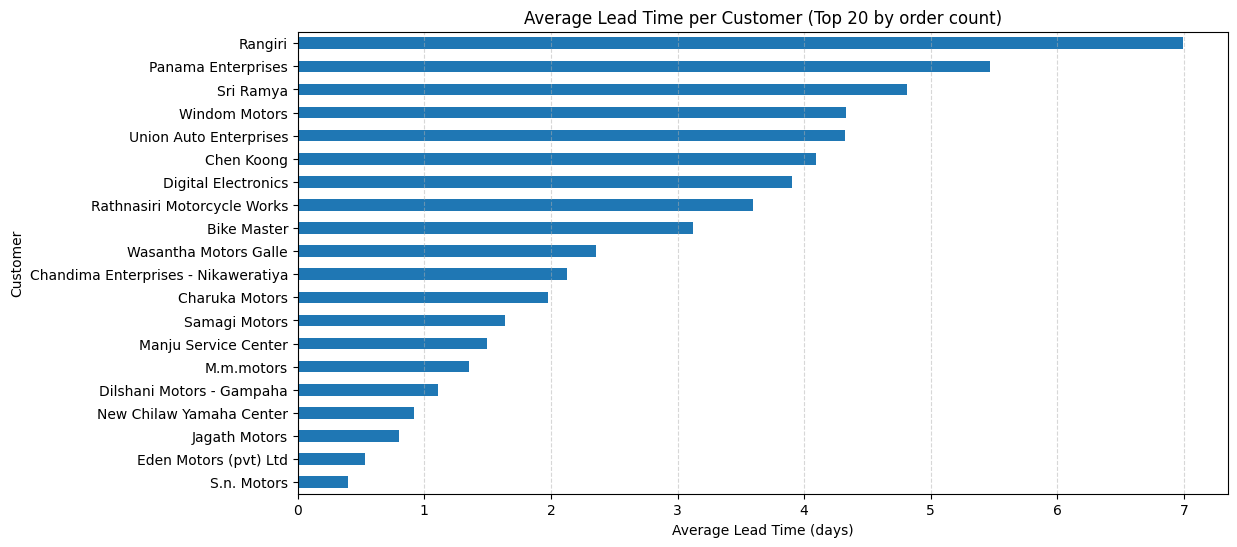

Sold-To Party Name
Union Auto Enterprises                 3059
S.n. Motors                             919
Manju Service Center                    731
Rangiri                                 712
Wasantha Motors Galle                   676
Rathnasiri Motorcycle Works             664
Digital Electronics                     634
Chandima Enterprises - Nikaweratiya     625
Chen Koong                              611
Windom Motors                           605
Dilshani Motors - Gampaha               582
Sri Ramya                               568
Charuka Motors                          566
Panama Enterprises                      562
Samagi Motors                           557
Bike Master                             534
New Chilaw Yamaha Center                524
Eden Motors (pvt) Ltd                   524
M.m.motors                              524
Jagath Motors                           501
Gunawardana Sons                        490
Union Motors                            485
Modern  Motor

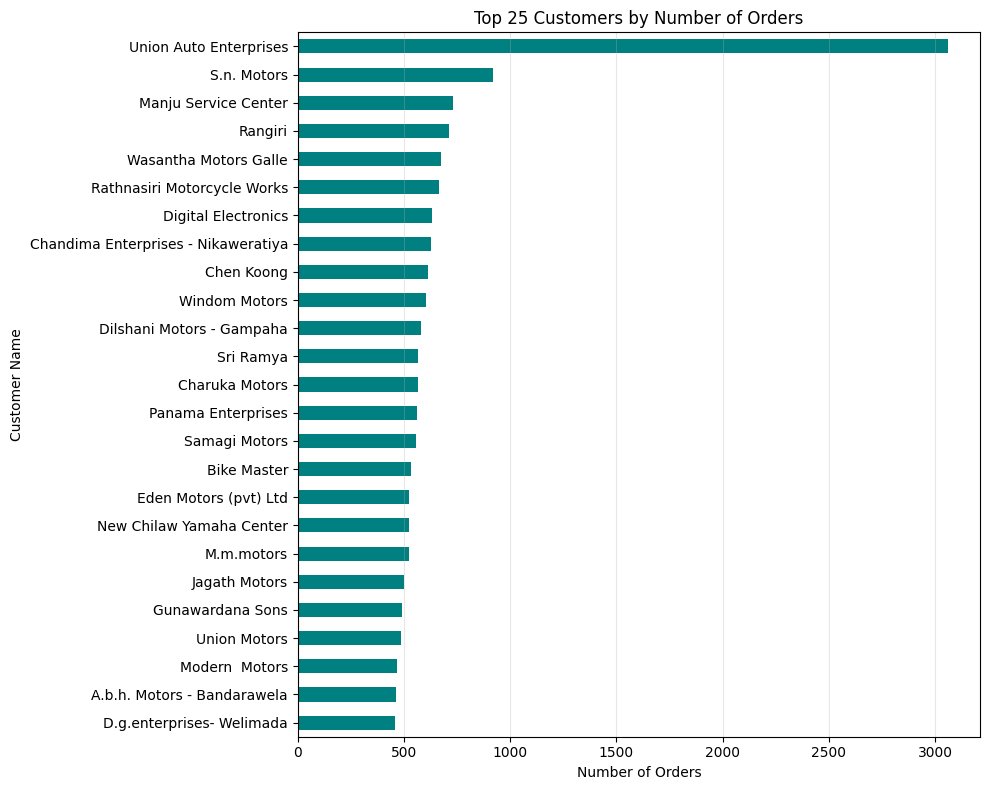


Number of rows with negative Lead Time: 0

Average Lead Time by Sales Document Type
Sales Document Type
ZP1A    4.746613
ZP2A    1.466268
ZRE     0.000000
Name: Lead Time, dtype: float64

Average Lead Time by Sold-To Party Name
Sold-To Party Name
Nalinda Super Motors                 109.091346
Police Transport Division - Parts    102.000000
New Nikko Motors                      50.947581
New Indika Motors                     30.608434
Gasith Rent A Car And cab service     25.974359
Jayani Motors                         20.000000
Anuradha Motors                       20.000000
Rienze Motors                         15.184211
Hemsi Group                           12.943343
Jaya Sri  Motors                      12.666667
Name: Lead Time, dtype: float64

Average Lead Time by Overall Status
Overall Status
B    4.955663
C    2.878160
A    2.621495
Name: Lead Time, dtype: float64

Orders with Lead Time > 30 days: 1160


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove rows where Lead Time is missing (optional but recommended)
clean_orders = orders_df[orders_df['Lead Time'].notna()].copy()

# 1. Basic statistics
print("Lead Time Statistics (days)")
print(clean_orders['Lead Time'].describe())

# 2. Histogram – y‑axis = number of orders
plt.figure(figsize=(10,5))
plt.hist(clean_orders['Lead Time'], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Lead Time')
plt.grid(True, linestyle='--', alpha=0.25)
plt.show()

# 3. Boxplot – y‑axis = lead time in days
plt.figure(figsize=(8,5))
sns.boxplot(y=clean_orders['Lead Time'])
plt.ylabel('Lead Time (days)')
plt.title('Boxplot of Lead Time')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. Average lead time by customer (top 20 customers by number of orders)
top_customers = clean_orders['Sold-To Party Name'].value_counts().head(20).index
avg_by_customer = clean_orders[clean_orders['Sold-To Party Name'].isin(top_customers)] \
                  .groupby('Sold-To Party Name')['Lead Time'].mean().sort_values()

# 5. Average Lead Time per Customer (Top 20 by order count)
plt.figure(figsize=(12,6))
avg_by_customer.plot(kind='barh')
plt.xlabel('Average Lead Time (days)')
plt.ylabel('Customer')
plt.title('Average Lead Time per Customer (Top 20 by order count)')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.show()

# Count orders per customer
customer_counts = orders_df['Sold-To Party Name'].value_counts().head(25)

# Display the counts
print(customer_counts)

plt.figure(figsize=(10, 8))
customer_counts.sort_values().plot(kind='barh', color='teal')
plt.title('Top 25 Customers by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()


# 6. Check for negative lead times (data errors or returns)
neg_lead = orders_df[orders_df['Lead Time'] < 0]
print(f"\nNumber of rows with negative Lead Time: {len(neg_lead)}")


# 7. Average lead time by key categories
#    (choose columns that make sense for your business)
for col in ['Sales Document Type', 'Sold-To Party Name', 'Overall Status']:
    print(f"\nAverage Lead Time by {col}")
    avg = orders_df.groupby(col)['Lead Time'].mean().sort_values(ascending=False).head(10)
    print(avg)

# 5. Optional: flag outliers (e.g., > 30 days)
orders_df['Is Long Lead'] = orders_df['Lead Time'] > 30
long_lead = orders_df[orders_df['Is Long Lead']]
print(f"\nOrders with Lead Time > 30 days: {len(long_lead)}")

In [49]:
# 1. Keep only rows with valid lead times
lead_df = orders_df[['Sold-To Party Name', 'Lead Time']].dropna(subset=['Lead Time'])

# 2. Group by customer and calculate statistics
customer_lead_summary = lead_df.groupby('Sold-To Party Name')['Lead Time'].agg(
    min_lead_time='min',
    max_lead_time='max',
    avg_lead_time='mean',
    total_orders='count',
    positive_orders=lambda x: (x > 0).sum()
).reset_index()

# 3. Round average for readability
customer_lead_summary['avg_lead_time'] = customer_lead_summary['avg_lead_time'].round(2)

# 4. Optional: add a column for percentage of positive orders
customer_lead_summary['positive_pct'] = (
    customer_lead_summary['positive_orders'] / customer_lead_summary['total_orders'] * 100
).round(1)

# 5. View the result
print(customer_lead_summary.head(10))  # first 10 rows

# 6. Save to CSV for further use
customer_lead_summary.to_csv('customer_lead_time_analysis.csv', index=False)

                Sold-To Party Name  min_lead_time  max_lead_time  \
0  A M A MOTORS (PRIVATE ) LIMITED            0.0            0.0   
1      A.b.h. Motors - Bandarawela            0.0           40.0   
2                     A.h.s.motors            0.0           24.0   
3                      A.j. Motors            0.0           17.0   
4           A.m.f.motors (pvt) Ltd            0.0           13.0   
5            Agra Auto Enterprises            0.0            0.0   
6  Ajantha Motots & Service Center            0.0           81.0   
7                     Akash Motors            0.0            3.0   
8                     Amaya Motors            0.0            7.0   
9                     Amila Marine            0.0           21.0   

   avg_lead_time  total_orders  positive_orders  positive_pct  
0           0.00             2                0           0.0  
1           0.82           462               73          15.8  
2           2.31            26               11          42

In [50]:
# Ensure you already have orders_df and the 'Lead Time' column
import pandas as pd

# 1. Keep only rows with valid lead times and needed columns
part_df = orders_df[['Material', 'Material Description', 'Lead Time']].dropna(subset=['Lead Time'])

# 2. Group by material (and description) and calculate statistics
part_lead_summary = part_df.groupby(['Material', 'Material Description'])['Lead Time'].agg(
    min_lead_time='min',
    max_lead_time='max',
    avg_lead_time='mean',
    total_orders='count',
    positive_orders=lambda x: (x > 0).sum()
).reset_index()

# 3. Round average to 2 decimals
part_lead_summary['avg_lead_time'] = part_lead_summary['avg_lead_time'].round(2)

# 4. Optional: percentage of positive orders
part_lead_summary['positive_pct'] = (
    part_lead_summary['positive_orders'] / part_lead_summary['total_orders'] * 100
).round(1)

# 5. View first rows
print(part_lead_summary.head(10))

# 6. Save to CSV for further analysis
part_lead_summary.to_csv('part_lead_time_analysis.csv', index=False)

      Material           Material Description  min_lead_time  max_lead_time  \
0  01550M0835A  BOLT,INTAKE MANIFOLD M A-STAR            9.0            9.0   
1  09103M10028          BOLT (10X20) M 800 MC            9.0            9.0   
2  09111M08090         BOLT CONT SHAFT M ALTO            9.0            9.0   
3  09117M12006             BOLT CALIPER M 800            9.0            9.0   
4  09140M12040                WHEEL NUT M 410           11.0           37.0   
5  09159M12042                     NUT M ALTO           10.0           10.0   
6  09159M16004   NUT,COUNTERSHAFT M ESTILO MC            9.0            9.0   
7  09168M14012               GASKET OIL DRAIN            0.0            1.0   
8  09247M14027          PLUG OIL DRAIN M ALTO           10.0           10.0   
9  09283M35032            OIL SEAL DIF: M 800            0.0            0.0   

   avg_lead_time  total_orders  positive_orders  positive_pct  
0            9.0             1                1         100.0  
1 

['Requested P/No', 'sss', 'Latest Part No /JAN', 'Special', 'Description', 'Qty', 'EOD ', 'Stock ', 'On orders w.repl ', 'Revised Order Qty ', 'New QTY (If need to change)', 'Forcasted Monthly sales qty - B2B / WS', 'Compatible models']
             Material                   part_description                       models  total_orders  positive_orders  min_lead  max_lead  avg_lead  median_lead  positive_pct
2533        571901NAE                 YAMALUBE 20W40 YAM                      Unknown           856              192       0.0     101.0       2.0          0.0          22.4
2534        571902NAE                 YAMALUBE 10W40 YAM                      Unknown           688              170       0.0     101.0       2.6          0.0          24.7
2532        571837NAE              YAMALUBE MB 10W40 YAM                      Unknown           463              110       0.0     101.0       2.2          0.0          23.8
328      1GC-E7632-01                             WEIGHT  Ray ZR,Ra

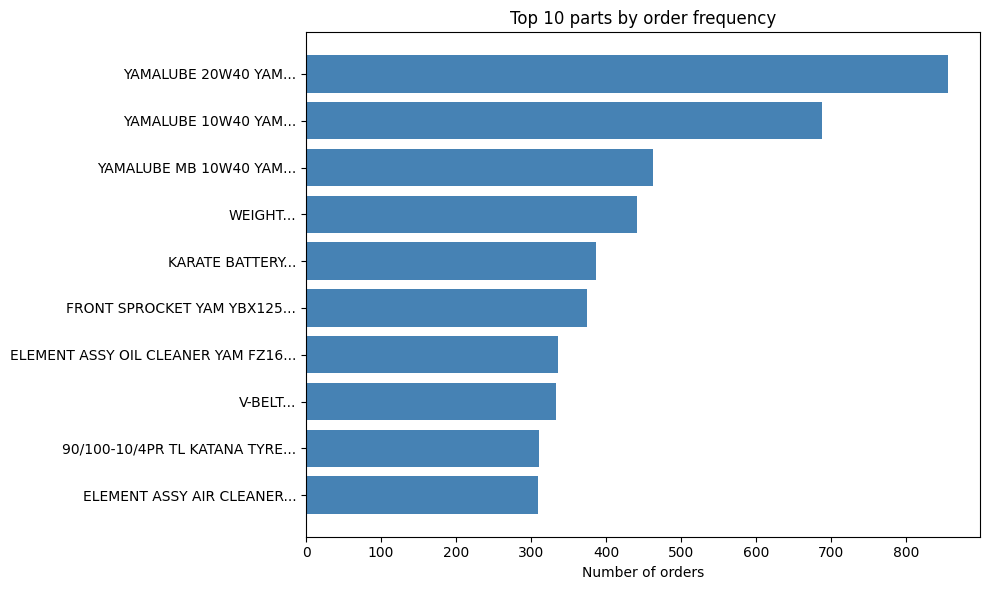

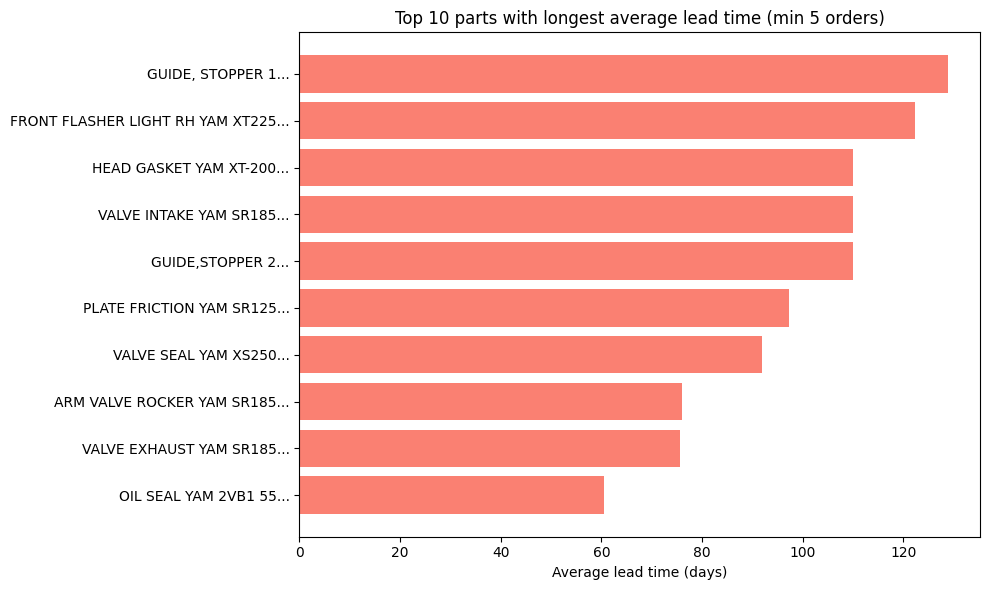

<Figure size 1000x600 with 0 Axes>

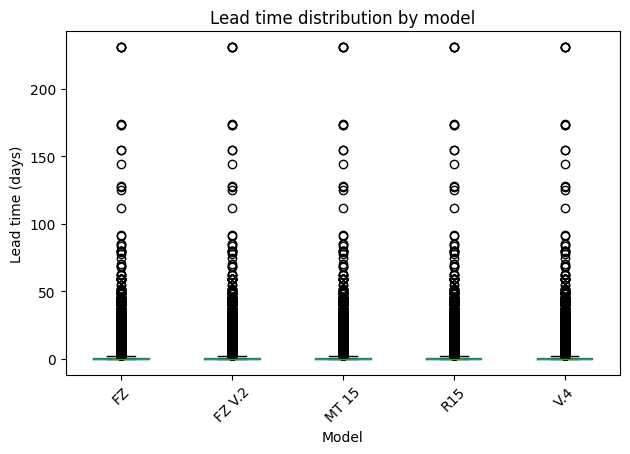

In [59]:
# ----- 1. Load the SSOP file -----
ssop_df = pd.read_excel("SSOP.xlsx")

# Look at its columns
print(ssop_df.columns.tolist())
# We are interested in: 'Requested P/No', 'Description', 'Compatible models'

# ----- 2. Prepare a clean part number column in SSOP -----
# Use 'Requested P/No' as the main identifier; sometimes it may be updated.
ssop_df['PartNumber'] = ssop_df['Requested P/No'].astype(str).str.strip()

# Keep only necessary columns to avoid duplication
ssop_clean = ssop_df[['PartNumber', 'Description', 'Compatible models']].copy()
# Drop duplicates (same part may appear multiple times; take first)
ssop_clean = ssop_clean.drop_duplicates(subset='PartNumber')

# ----- 3. Merge with orders_df -----
# orders_df already contains 'Material' and 'Lead Time'
orders_df['Material'] = orders_df['Material'].astype(str).str.strip()

merged_df = orders_df.merge(ssop_clean, left_on='Material', right_on='PartNumber', how='left')

# Now we have a column 'Compatible models' (may contain NaN if no match)

# ----- 4. Part‑wise lead time statistics -----
# Keep only rows with valid lead time
part_stats = merged_df[merged_df['Lead Time'].notna()].copy()

# Group by part number (Material) and include the model info (take first non‑null)
part_summary = part_stats.groupby('Material').agg(
    part_description=('Material Description', 'first'),
    models=('Compatible models', lambda x: x.dropna().iloc[0] if any(x.notna()) else 'Unknown'),
    total_orders=('Lead Time', 'count'),
    positive_orders=('Lead Time', lambda x: (x > 0).sum()),
    min_lead=('Lead Time', 'min'),
    max_lead=('Lead Time', 'max'),
    avg_lead=('Lead Time', 'mean'),
    median_lead=('Lead Time', 'median')
).reset_index()

# Round averages
part_summary['avg_lead'] = part_summary['avg_lead'].round(1)
part_summary['median_lead'] = part_summary['median_lead'].round(1)

# Add positive percentage
part_summary['positive_pct'] = (part_summary['positive_orders'] / part_summary['total_orders'] * 100).round(1)

# Sort by total orders descending to see most frequent parts
part_summary = part_summary.sort_values('total_orders', ascending=False)

# Display top 20
print(part_summary.head(20).to_string())

# Save to CSV for further use
part_summary.to_csv('part_lead_time_with_models.csv', index=False)

# Create a copy where we split the 'Compatible models' into a list
model_df = part_stats.copy()
model_df['models_list'] = model_df['Compatible models'].str.split(',')

# Explode so each model gets its own row
model_exploded = model_df.explode('models_list')
# Clean up model names (strip whitespace)
model_exploded['models_list'] = model_exploded['models_list'].str.strip()

# Remove rows where model is empty or NaN
model_exploded = model_exploded[model_exploded['models_list'].notna() & (model_exploded['models_list'] != '')]

# Now we can compute model‑wise statistics
model_stats = model_exploded.groupby('models_list')['Lead Time'].agg(
    total_orders='count',
    avg_lead='mean',
    median_lead='median',
    min_lead='min',
    max_lead='max'
).reset_index().sort_values('total_orders', ascending=False)

model_stats['avg_lead'] = model_stats['avg_lead'].round(1)
model_stats['median_lead'] = model_stats['median_lead'].round(1)

print("\nModel‑wise lead time summary:")
print(model_stats.head(10).to_string())

# Save model summary
model_stats.to_csv('model_lead_time_summary.csv', index=False)

top_parts = part_summary.head(10)

plt.figure(figsize=(10,6))
plt.barh(range(len(top_parts)), top_parts['total_orders'].values, color='steelblue')
plt.yticks(range(len(top_parts)), top_parts['part_description'].str[:40] + '...')
plt.xlabel('Number of orders')
plt.title('Top 10 parts by order frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

freq_parts = part_summary[part_summary['total_orders'] >= 5].copy()
long_lead = freq_parts.nlargest(10, 'avg_lead')

plt.figure(figsize=(10,6))
plt.barh(range(len(long_lead)), long_lead['avg_lead'].values, color='salmon')
plt.yticks(range(len(long_lead)), long_lead['part_description'].str[:40] + '...')
plt.xlabel('Average lead time (days)')
plt.title('Top 10 parts with longest average lead time (min 5 orders)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_models = model_stats.head(5)['models_list'].tolist()
model_subset = model_exploded[model_exploded['models_list'].isin(top_models)]

plt.figure(figsize=(10,6))
model_subset.boxplot(column='Lead Time', by='models_list', grid=False)
plt.title('Lead time distribution by model')
plt.suptitle('')
plt.xlabel('Model')
plt.ylabel('Lead time (days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total lost quantity across all orders: 149,162
Average lost quantity per order: 2.84
Orders with lost quantity (>0): 15708
Orders with over‑delivery (<0): 0

Top 10 parts by total lost quantity:
       Material                          part_desc                      models  total_orders  total_lost  avg_lost  max_lost
   1GC-E7632-01                             WEIGHT Ray ZR,Ray ZR Street Rallay           441      5836.0     13.23     350.0
   21C-E3440-01           ELEMENT ASSY OIL CLEANER   FZ V.2,MT 15,FZ,V.4, R15,           198      5288.0     26.71     300.0
    94702-00217 S. PLUG (B7HS-10) YAMAHA 9.9/15 HP                     Unknown            80      4978.0     62.22    1000.0
    94702-00040            PLUG SPARK YAMAHA 40 HP                     Unknown            48      4958.0    103.29    1000.0
21C-E3440-01-00  ELEMENT ASSY OIL CLEANER YAM FZ16                     Unknown           336      4890.0     14.55     200.0
    94701-00254                PLUG, SPARK (C7HSA)     

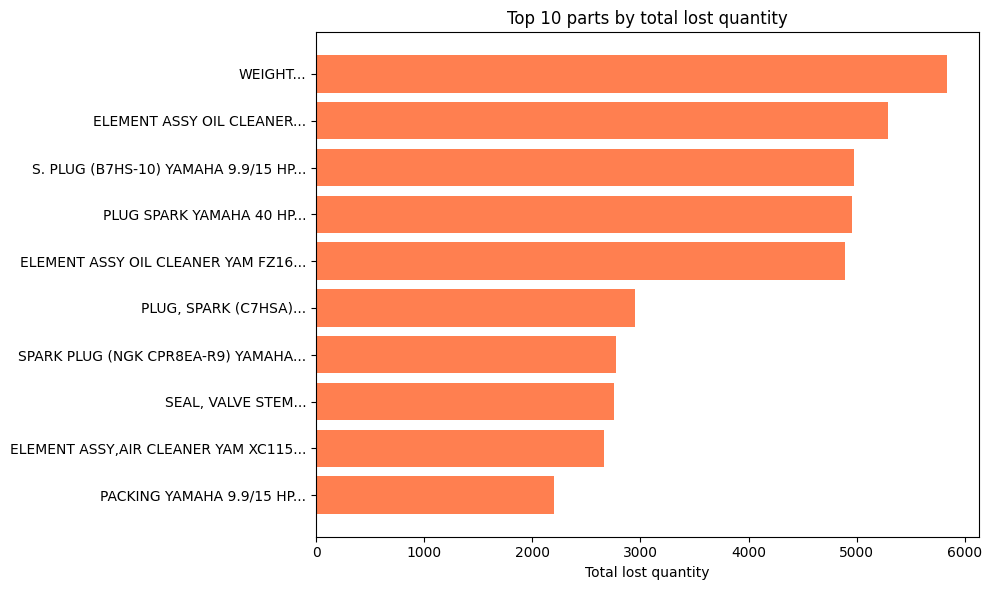


Top 10 customers by total lost quantity:
                 Sold-To Party Name  total_orders  total_lost  avg_lost
             Union Auto Enterprises          3059      8033.0  2.626022
           New Chilaw Yamaha Center           524      5414.0 10.332061
                    Azhakan Traders           339      3906.0 11.522124
                  New Indika Motors           332      2951.0  8.888554
                         Chen Koong           611      2913.0  4.767594
              Wasantha Motors Galle           676      2871.0  4.247041
Chandima Enterprises - Nikaweratiya           625      2676.0  4.281600
                        S.n. Motors           919      2601.0  2.830250
                        Hemsi Group           353      2577.0  7.300283
               Manju Service Center           731      2570.0  3.515732


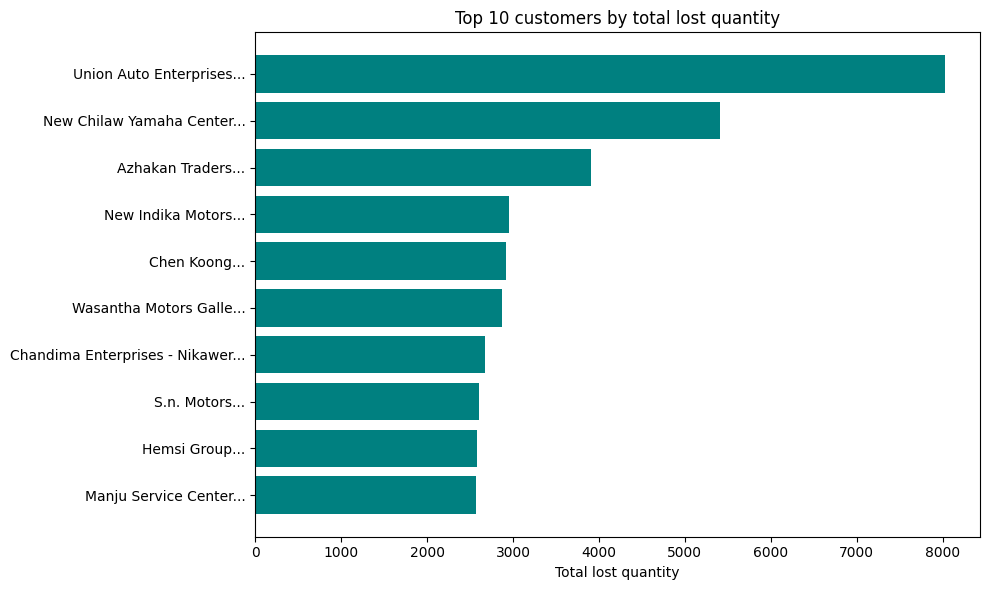


Top 10 models by total lost quantity:
              models  total_orders  total_lost  avg_lost
                  FZ         10370     32390.4  3.123472
              FZ V.2         10370     32390.4  3.123472
               MT 15         10370     32390.4  3.123472
                 R15         10370     32390.4  3.123472
                 V.4         10370     32390.4  3.123472
              Ray ZR          7071     27303.0  3.861264
Ray ZR Street Rallay          7071     27303.0  3.861264
              COMMON           856      7078.0  8.268692


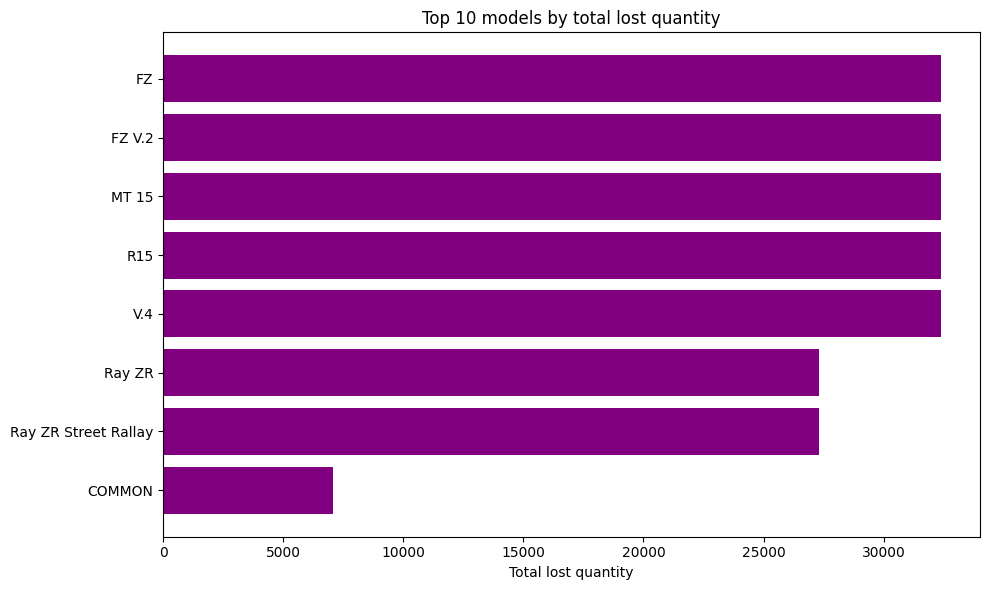

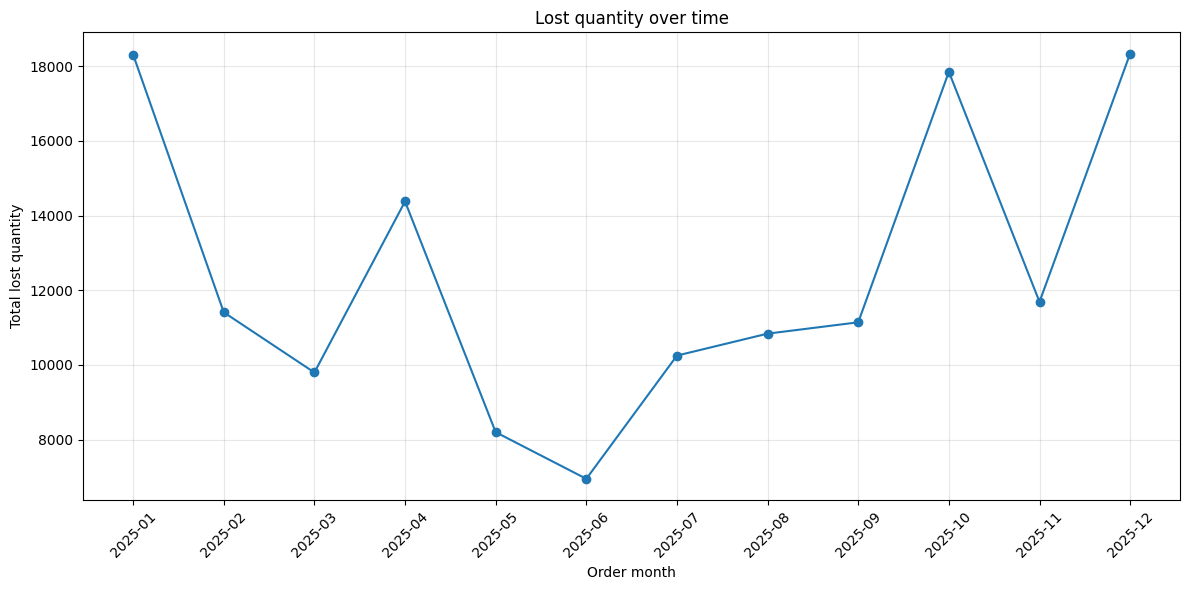

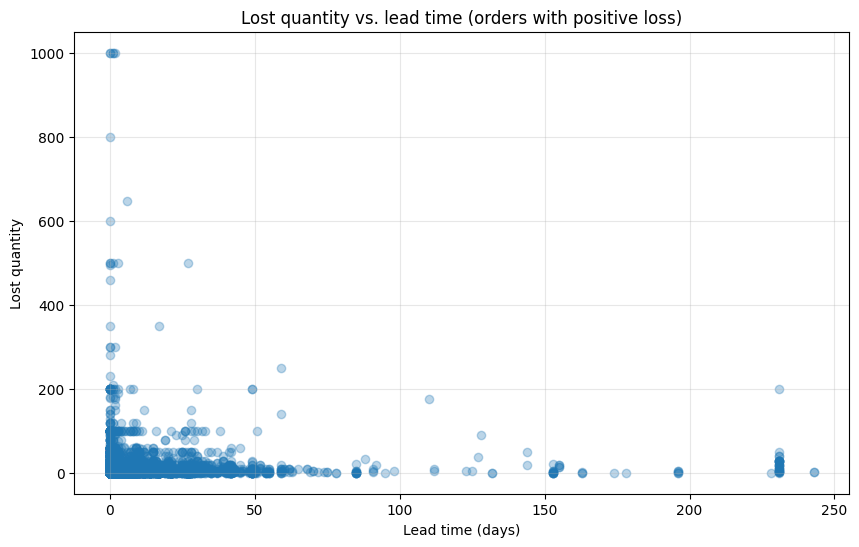

In [64]:
ssop_df['PartNumber'] = ssop_df['Requested P/No'].astype(str).str.strip()
ssop_clean = ssop_df[['PartNumber', 'Compatible models']].drop_duplicates(subset='PartNumber')

# Merge
orders_df['Material'] = orders_df['Material'].astype(str).str.strip()
merged_df = orders_df.merge(ssop_clean, left_on='Material', right_on='PartNumber', how='left')

# Basic stats
total_lost = merged_df['Lost Qty'].sum()
avg_lost_per_order = merged_df['Lost Qty'].mean()
orders_with_loss = (merged_df['Lost Qty'] > 0).sum()
orders_with_overdelivery = (merged_df['Lost Qty'] < 0).sum()

print(f"Total lost quantity across all orders: {total_lost:,.0f}")
print(f"Average lost quantity per order: {avg_lost_per_order:.2f}")
print(f"Orders with lost quantity (>0): {orders_with_loss}")
print(f"Orders with over‑delivery (<0): {orders_with_overdelivery}")

# Group by part number
part_lost = merged_df.groupby('Material').agg(
    part_desc=('Material Description', 'first'),
    models=('Compatible models', lambda x: x.dropna().iloc[0] if any(x.notna()) else 'Unknown'),
    total_orders=('Lost Qty', 'count'),
    total_lost=('Lost Qty', 'sum'),
    avg_lost=('Lost Qty', 'mean'),
    max_lost=('Lost Qty', 'max')
).reset_index()

part_lost = part_lost.sort_values('total_lost', ascending=False)
part_lost['avg_lost'] = part_lost['avg_lost'].round(2)

print("\nTop 10 parts by total lost quantity:")
print(part_lost.head(10).to_string(index=False))

# Visualize
top10_parts = part_lost.head(10)
plt.figure(figsize=(10,6))
plt.barh(range(len(top10_parts)), top10_parts['total_lost'].values, color='coral')
plt.yticks(range(len(top10_parts)), top10_parts['part_desc'].str[:40] + '...')
plt.xlabel('Total lost quantity')
plt.title('Top 10 parts by total lost quantity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

cust_lost = merged_df.groupby('Sold-To Party Name').agg(
    total_orders=('Lost Qty', 'count'),
    total_lost=('Lost Qty', 'sum'),
    avg_lost=('Lost Qty', 'mean')
).reset_index().sort_values('total_lost', ascending=False)

print("\nTop 10 customers by total lost quantity:")
print(cust_lost.head(10).to_string(index=False))

# Bar chart
top10_cust = cust_lost.head(10)
plt.figure(figsize=(10,6))
plt.barh(range(len(top10_cust)), top10_cust['total_lost'].values, color='teal')
plt.yticks(range(len(top10_cust)), top10_cust['Sold-To Party Name'].str[:30] + '...')
plt.xlabel('Total lost quantity')
plt.title('Top 10 customers by total lost quantity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Create exploded model column
model_df = merged_df.copy()
model_df['models'] = model_df['Compatible models'].str.split(',')

# Explode so each model gets its own row
model_exploded = model_df.explode('models')
model_exploded['models'] = model_exploded['models'].str.strip()
model_exploded = model_exploded[model_exploded['models'].notna() & (model_exploded['models'] != '')]

# Aggregate by model
model_lost = model_exploded.groupby('models').agg(
    total_orders=('Lost Qty', 'count'),
    total_lost=('Lost Qty', 'sum'),
    avg_lost=('Lost Qty', 'mean')
).reset_index().sort_values('total_lost', ascending=False)

print("\nTop 10 models by total lost quantity:")
print(model_lost.head(10).to_string(index=False))

# Bar chart
top10_models = model_lost.head(10)
plt.figure(figsize=(10,6))
plt.barh(range(len(top10_models)), top10_models['total_lost'].values, color='purple')
plt.yticks(range(len(top10_models)), top10_models['models'])
plt.xlabel('Total lost quantity')
plt.title('Top 10 models by total lost quantity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Create a monthly period (or daily) to see trend
merged_df['Order Month'] = merged_df['Created On'].dt.to_period('M')
monthly_lost = merged_df.groupby('Order Month')['Lost Qty'].sum().reset_index()
monthly_lost['Order Month'] = monthly_lost['Order Month'].astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_lost['Order Month'], monthly_lost['Lost Qty'], marker='o')
plt.xlabel('Order month')
plt.ylabel('Total lost quantity')
plt.title('Lost quantity over time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter plot: lost qty vs lead time for orders with positive lost
pos_lost = merged_df[merged_df['Lost Qty'] > 0].copy()
plt.figure(figsize=(10,6))
plt.scatter(pos_lost['Lead Time'], pos_lost['Lost Qty'], alpha=0.3)
plt.xlabel('Lead time (days)')
plt.ylabel('Lost quantity')
plt.title('Lost quantity vs. lead time (orders with positive loss)')
plt.grid(True, alpha=0.3)
plt.show()